In [81]:
# import math
# import torch
# import pyro
# import pyro.distributions as dist
# from pyro.infer import SVI, Trace_ELBO, Predictive
# from pyro.infer.autoguide import AutoDiagonalNormal
# from pyro.optim import ClippedAdam
# import matplotlib.pyplot as plt



In [82]:

# # -----------------------------
# # 1. Настройки
# # -----------------------------

# pyro.clear_param_store()
# pyro.set_rng_seed(42)
# torch.manual_seed(42)

# # Число обучающих точек
# N_train = 60

# # Число нейронов в скрытом слое
# H = 50

# # Число итераций SVI
# num_steps = 5000



In [83]:

# # -----------------------------
# # 2. Искусственные данные
# # -----------------------------

# def true_function(x):
#     return torch.sin(2.5 * x) + 0.3 * x


# noise_std = 0.20

# x_train = -3.0 + 6.0 * torch.rand(N_train, 1)
# y_clean = true_function(x_train)
# y_train = y_clean + noise_std * torch.randn_like(y_clean)

# # Тестовая сетка
# x_test = torch.linspace(-3.0, 3.0, 200).unsqueeze(-1)
# y_test_true = true_function(x_test)
# y_test = y_test_true + noise_std * torch.randn_like(y_test_true)

# # Для визуализации возьмём область шире train-диапазона
# x_grid = torch.linspace(-4.0, 4.0, 400).unsqueeze(-1)
# y_grid_true = true_function(x_grid)



In [84]:

# # -----------------------------
# # 3. Нормализация
# # -----------------------------
# # Для BNN/BRANN это очень желательно.

# x_loc = x_train.mean(dim=0, keepdim=True)
# x_scale = x_train.std(dim=0, keepdim=True)

# y_loc = y_train.mean()
# y_scale = y_train.std()

# X_train = (x_train - x_loc) / x_scale
# Y_train = ((y_train - y_loc) / y_scale).squeeze(-1)

# X_test = (x_test - x_loc) / x_scale
# X_grid = (x_grid - x_loc) / x_scale

# noise_std_scaled = noise_std / y_scale.item()
# beta_mean0 = 1.0 / (noise_std_scaled ** 2)

# print("y_scale:", y_scale.item())
# print("noise_std_scaled:", noise_std_scaled)
# print("suggested beta mean:", beta_mean0)


# def inv_y(z):
#     return z * y_scale + y_loc



In [85]:

# # -----------------------------
# # 4. BRANN-like Pyro model
# # -----------------------------

# def brann_model(X, y=None):
#     """
#     Байесовская MLP-регрессия.

#     alpha ~ Gamma(...)
#         precision для весов.
#         Чем больше alpha, тем сильнее веса прижимаются к нулю.

#     beta ~ Gamma(...)
#         precision шума наблюдений.
#         Чем больше beta, тем меньше предполагаемый шум.
#     """

#     N, D = X.shape

#     zero = X.new_tensor(0.0)
#     one = X.new_tensor(1.0)
#     two = X.new_tensor(2.0)

#     # Precision весов: аналог регуляризации alpha
#     alpha = pyro.sample("alpha", dist.Gamma(two, one))

#     # Precision шума данных: аналог beta
#     beta = pyro.sample("beta", dist.Gamma(two, one))

#     sigma_w = torch.rsqrt(alpha)
#     sigma_y = torch.rsqrt(beta)

#     # Первый слой
#     w1 = pyro.sample(
#         "w1",
#         dist.Normal(zero, sigma_w).expand([D, H]).to_event(2)
#     )

#     b1 = pyro.sample(
#         "b1",
#         dist.Normal(zero, sigma_w).expand([H]).to_event(1)
#     )

#     # Второй слой
#     w2 = pyro.sample(
#         "w2",
#         dist.Normal(zero, sigma_w).expand([H, 1]).to_event(2)
#     )

#     b2 = pyro.sample(
#         "b2",
#         dist.Normal(zero, sigma_w).expand([1]).to_event(1)
#     )

#     hidden = torch.tanh(X @ w1 + b1)
#     mu = (hidden @ w2 + b2).squeeze(-1)

#     # Сохраняем латентное среднее, чтобы потом строить интервалы
#     pyro.deterministic("mu", mu)

#     with pyro.plate("data", N):
#         pyro.sample("obs", dist.Normal(mu, sigma_y), obs=y)



In [86]:

# # -----------------------------
# # 5. Вариационный вывод
# # -----------------------------

# guide = AutoDiagonalNormal(brann_model)

# optimizer = ClippedAdam({
#     "lr": 0.01,
#     "clip_norm": 5.0
# })

# svi = SVI(
#     brann_model,
#     guide,
#     optimizer,
#     loss=Trace_ELBO()
# )

# for step in range(num_steps):
#     loss = svi.step(X_train, Y_train) / N_train

#     if step % 500 == 0:
#         print(f"step {step:5d} | loss = {loss:.4f}")



In [87]:

# # -----------------------------
# # 6. Предсказания
# # -----------------------------

# predictive = Predictive(
#     brann_model,
#     guide=guide,
#     num_samples=1000,
#     return_sites=("mu", "obs", "alpha", "beta")
# )

# samples_grid = predictive(X_grid)

# # mu — распределение латентной функции без шума наблюдений
# mu_samples_std = samples_grid["mu"]

# # obs — распределение новых наблюдений, включая шум
# obs_samples_std = samples_grid["obs"]

# # Обратно в исходную шкалу y
# mu_samples = inv_y(mu_samples_std)
# obs_samples = inv_y(obs_samples_std)

# pred_mean = mu_samples.mean(dim=0)
# pred_low = mu_samples.quantile(0.025, dim=0)
# pred_high = mu_samples.quantile(0.975, dim=0)

# obs_low = obs_samples.quantile(0.025, dim=0)
# obs_high = obs_samples.quantile(0.975, dim=0)



In [88]:

# # -----------------------------
# # 7. Метрика на тесте
# # -----------------------------

# samples_test = Predictive(
#     brann_model,
#     guide=guide,
#     num_samples=500,
#     return_sites=("mu",)
# )(X_test)

# test_mu = inv_y(samples_test["mu"]).mean(dim=0)

# rmse_noisy = torch.sqrt(torch.mean((test_mu - y_test.squeeze(-1)) ** 2))
# rmse_true = torch.sqrt(torch.mean((test_mu - y_test_true.squeeze(-1)) ** 2))

# print()
# print(f"RMSE against noisy test y : {rmse_noisy.item():.4f}")
# print(f"RMSE against true function: {rmse_true.item():.4f}")



In [89]:

# # -----------------------------
# # 8. Посмотрим alpha и beta
# # -----------------------------

# alpha_samples = samples_grid["alpha"]
# beta_samples = samples_grid["beta"]

# alpha_mean = alpha_samples.mean().item()
# beta_mean = beta_samples.mean().item()

# sigma_w_mean = torch.rsqrt(alpha_samples).mean().item()
# sigma_noise_original = (torch.rsqrt(beta_samples) * y_scale).mean().item()

# print()
# print(f"posterior mean alpha        : {alpha_mean:.4f}")
# print(f"posterior mean beta         : {beta_mean:.4f}")
# print(f"posterior mean sigma_w      : {sigma_w_mean:.4f}")
# print(f"posterior mean noise std y  : {sigma_noise_original:.4f}")
# print(f"true noise std              : {noise_std:.4f}")



In [90]:

# # -----------------------------
# # 9. График
# # -----------------------------

# x_grid_np = x_grid.squeeze(-1).detach().cpu().numpy()

# pred_mean_np = pred_mean.detach().cpu().squeeze().numpy()
# pred_low_np = pred_low.detach().cpu().squeeze().numpy()
# pred_high_np = pred_high.detach().cpu().squeeze().numpy()

# obs_low_np = obs_low.detach().cpu().squeeze().numpy()
# obs_high_np = obs_high.detach().cpu().squeeze().numpy()


# plt.figure(figsize=(10, 6))

# plt.scatter(
#     x_train.squeeze(-1).numpy(),
#     y_train.squeeze(-1).numpy(),
#     s=35,
#     alpha=0.8,
#     label="train data"
# )

# plt.plot(
#     x_grid_np,
#     y_grid_true.squeeze(-1).numpy(),
#     "k--",
#     linewidth=2,
#     label="true function"
# )

# plt.plot(
#     x_grid_np,
#     pred_mean_np,
#     color="tab:blue",
#     linewidth=2,
#     label="BRANN/BNN posterior mean"
# )

# plt.fill_between(
#     x_grid_np,
#     pred_low_np,
#     pred_high_np,
#     color="tab:blue",
#     alpha=0.25,
#     label="95% latent function interval"
# )

# plt.fill_between(
#     x_grid_np,
#     obs_low_np,
#     obs_high_np,
#     color="tab:orange",
#     alpha=0.15,
#     label="95% predictive interval with noise"
# )

# plt.axvline(-3, color="gray", linestyle=":", linewidth=1)
# plt.axvline(3, color="gray", linestyle=":", linewidth=1)

# plt.title("Artificial BRANN-like Bayesian Neural Network test in Pyro")
# plt.xlabel("x")
# plt.ylabel("y")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()


In [91]:
import math
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.optim import ClippedAdam
import matplotlib.pyplot as plt


pyro.clear_param_store()
pyro.set_rng_seed(42)
torch.manual_seed(42)

# Число обучающих точек
N_train = 60

# Число нейронов в скрытом слое
H = 10

# Число итераций SVI
num_steps = 10000


# -----------------------------
# 2. Искусственные данные
# -----------------------------


In [92]:

def true_function(x):
    return torch.sin(2.5 * x) + 0.3 * x


noise_std = 0.20

x_train = -3.0 + 6.0 * torch.rand(N_train, 1)
y_clean = true_function(x_train)
y_train = y_clean + noise_std * torch.randn_like(y_clean)

# Тестовая сетка
x_test = torch.linspace(-3.0, 3.0, 200).unsqueeze(-1)
y_test_true = true_function(x_test)
y_test = y_test_true + noise_std * torch.randn_like(y_test_true)

# Для визуализации возьмём область шире train-диапазона
x_grid = torch.linspace(-4.0, 4.0, 400).unsqueeze(-1)
y_grid_true = true_function(x_grid)

# нормализация

In [93]:

# -----------------------------
# 3. Нормализация
# -----------------------------
# Для BNN/BRANN это очень желательно.

x_loc = x_train.mean(dim=0, keepdim=True)
x_scale = x_train.std(dim=0, keepdim=True)

y_loc = y_train.mean()
y_scale = y_train.std()

X_train = (x_train - x_loc) / x_scale
Y_train = ((y_train - y_loc) / y_scale).squeeze(-1)

X_test = (x_test - x_loc) / x_scale
X_grid = (x_grid - x_loc) / x_scale

noise_std_scaled = noise_std / y_scale.item()
beta_mean0 = 1.0 / (noise_std_scaled ** 2)

# prior на beta: среднее около истинного precision шума
beta_shape0 = 30.0
beta_rate0 = beta_shape0 / beta_mean0

# prior на alpha: хотим не слишком сильную регуляризацию
# alpha_mean=0.3 => sigma_w ~= 1/sqrt(0.3) ~= 1.83
alpha_mean0 = 0.1
alpha_shape0 = 2.0
alpha_rate0 = alpha_shape0 / alpha_mean0

print("alpha prior mean:", alpha_shape0 / alpha_rate0)
print("beta prior mean :", beta_shape0 / beta_rate0)

def inv_y(z):
    return z * y_scale + y_loc


alpha prior mean: 0.1
beta prior mean : 18.476332101363365


In [94]:

def brann_model(X, y=None):
    N, D = X.shape

    zero = X.new_tensor(0.0)

    alpha_shape = X.new_tensor(alpha_shape0)
    alpha_rate = X.new_tensor(alpha_rate0)

    beta_shape = X.new_tensor(beta_shape0)
    beta_rate = X.new_tensor(beta_rate0)

    alpha = pyro.sample(
        "alpha",
        dist.Gamma(alpha_shape, alpha_rate)
    )

    beta = pyro.sample(
        "beta",
        dist.Gamma(beta_shape, beta_rate)
    )

    sigma_w = torch.rsqrt(alpha)
    sigma_y = torch.rsqrt(beta)

    # Fan-in scaling.
    # Это важно, особенно для второго слоя.
    w1_scale = sigma_w / math.sqrt(D)
    w2_scale = sigma_w / math.sqrt(H)

    b1_scale = sigma_w
    b2_scale = sigma_w

    w1 = pyro.sample(
        "w1",
        dist.Normal(zero, w1_scale).expand([D, H]).to_event(2)
    )

    b1 = pyro.sample(
        "b1",
        dist.Normal(zero, b1_scale).expand([H]).to_event(1)
    )

    w2 = pyro.sample(
        "w2",
        dist.Normal(zero, w2_scale).expand([H, 1]).to_event(2)
    )

    b2 = pyro.sample(
        "b2",
        dist.Normal(zero, b2_scale).expand([1]).to_event(1)
    )

    hidden = torch.tanh(X @ w1 + b1)
    mu = (hidden @ w2 + b2).squeeze(-1)

    pyro.deterministic("mu", mu)

    with pyro.plate("data", N):
        pyro.sample("obs", dist.Normal(mu, sigma_y), obs=y)


guide = AutoLowRankMultivariateNormal(
    brann_model,
    rank=20,
    init_scale=0.03
)
optimizer = ClippedAdam({
    "lr": 0.003,
    "clip_norm": 5.0
})

svi = SVI(
    brann_model,
    guide,
    optimizer,
    loss=Trace_ELBO(num_particles=4)
)

for step in range(num_steps):
    loss = svi.step(X_train, Y_train) / N_train

    if step % 500 == 0:
        print(f"step {step:5d} | loss = {loss:.4f}")


# -----------------------------
# 6. Предсказания
# -----------------------------

predictive = Predictive(
    brann_model,
    guide=guide,
    num_samples=1000,
    return_sites=("mu", "obs", "alpha", "beta")
)

samples_grid = predictive(X_grid)

# mu — распределение латентной функции без шума наблюдений
mu_samples_std = samples_grid["mu"]

# obs — распределение новых наблюдений, включая шум
obs_samples_std = samples_grid["obs"]

# Обратно в исходную шкалу y
mu_samples = inv_y(mu_samples_std)
obs_samples = inv_y(obs_samples_std)

pred_mean = mu_samples.mean(dim=0)
pred_low = mu_samples.quantile(0.025, dim=0)
pred_high = mu_samples.quantile(0.975, dim=0)

obs_low = obs_samples.quantile(0.025, dim=0)
obs_high = obs_samples.quantile(0.975, dim=0)


# -----------------------------
# 7. Метрика на тесте
# -----------------------------

samples_test = Predictive(
    brann_model,
    guide=guide,
    num_samples=500,
    return_sites=("mu",)
)(X_test)

test_mu = inv_y(samples_test["mu"]).mean(dim=0)

rmse_noisy = torch.sqrt(torch.mean((test_mu - y_test.squeeze(-1)) ** 2))
rmse_true = torch.sqrt(torch.mean((test_mu - y_test_true.squeeze(-1)) ** 2))

print()
print(f"RMSE against noisy test y : {rmse_noisy.item():.4f}")
print(f"RMSE against true function: {rmse_true.item():.4f}")


# -----------------------------
# 8. Посмотрим alpha и beta
# -----------------------------

alpha_samples = samples_grid["alpha"]
beta_samples = samples_grid["beta"]

alpha_mean = alpha_samples.mean().item()
beta_mean = beta_samples.mean().item()

sigma_w_mean = torch.rsqrt(alpha_samples).mean().item()
sigma_noise_original = (torch.rsqrt(beta_samples) * y_scale).mean().item()

print()
print(f"posterior mean alpha        : {alpha_mean:.4f}")
print(f"posterior mean beta         : {beta_mean:.4f}")
print(f"posterior mean sigma_w      : {sigma_w_mean:.4f}")
print(f"posterior mean noise std y  : {sigma_noise_original:.4f}")
print(f"true noise std              : {noise_std:.4f}")


step     0 | loss = 8.7595


KeyboardInterrupt: 

# график

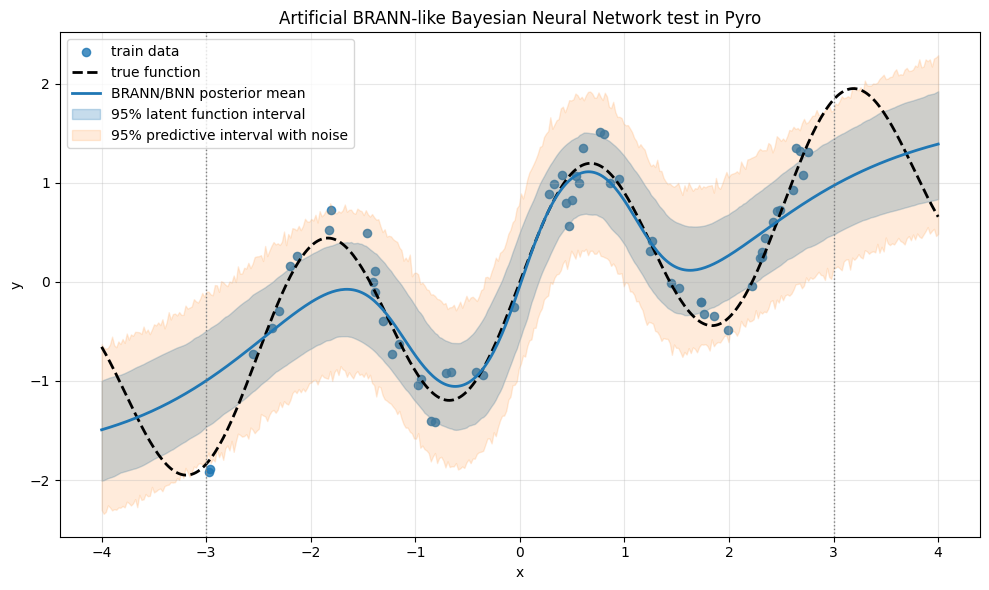

In [ ]:

# -----------------------------
# 9. График
# -----------------------------

x_grid_np = x_grid.squeeze(-1).detach().cpu().numpy()

pred_mean_np = pred_mean.detach().cpu().squeeze().numpy()
pred_low_np = pred_low.detach().cpu().squeeze().numpy()
pred_high_np = pred_high.detach().cpu().squeeze().numpy()

obs_low_np = obs_low.detach().cpu().squeeze().numpy()
obs_high_np = obs_high.detach().cpu().squeeze().numpy()


plt.figure(figsize=(10, 6))

plt.scatter(
    x_train.squeeze(-1).numpy(),
    y_train.squeeze(-1).numpy(),
    s=35,
    alpha=0.8,
    label="train data"
)

plt.plot(
    x_grid_np,
    y_grid_true.squeeze(-1).numpy(),
    "k--",
    linewidth=2,
    label="true function"
)

plt.plot(
    x_grid_np,
    pred_mean_np,
    color="tab:blue",
    linewidth=2,
    label="BRANN/BNN posterior mean"
)

plt.fill_between(
    x_grid_np,
    pred_low_np,
    pred_high_np,
    color="tab:blue",
    alpha=0.25,
    label="95% latent function interval"
)

plt.fill_between(
    x_grid_np,
    obs_low_np,
    obs_high_np,
    color="tab:orange",
    alpha=0.15,
    label="95% predictive interval with noise"
)

plt.axvline(-3, color="gray", linestyle=":", linewidth=1)
plt.axvline(3, color="gray", linestyle=":", linewidth=1)

plt.title("Artificial BRANN-like Bayesian Neural Network test in Pyro")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


step     0 | loss=12.5671 | alpha=0.1010 | beta=19.8010
step  1000 | loss=2.4161 | alpha=1.3092 | beta=25.5233
step  2000 | loss=2.2848 | alpha=1.5362 | beta=24.0809
step  3000 | loss=2.2508 | alpha=1.6140 | beta=23.3691
step  4000 | loss=2.2507 | alpha=1.6154 | beta=23.4063
step  5000 | loss=2.2489 | alpha=1.6157 | beta=23.4346
step  6000 | loss=2.2486 | alpha=1.6163 | beta=23.4333
step  7000 | loss=2.2468 | alpha=1.6177 | beta=23.5247

Final alpha: 1.6233
Final beta : 23.5033
Estimated noise std in original scale: 0.1773
True noise std: 0.2000


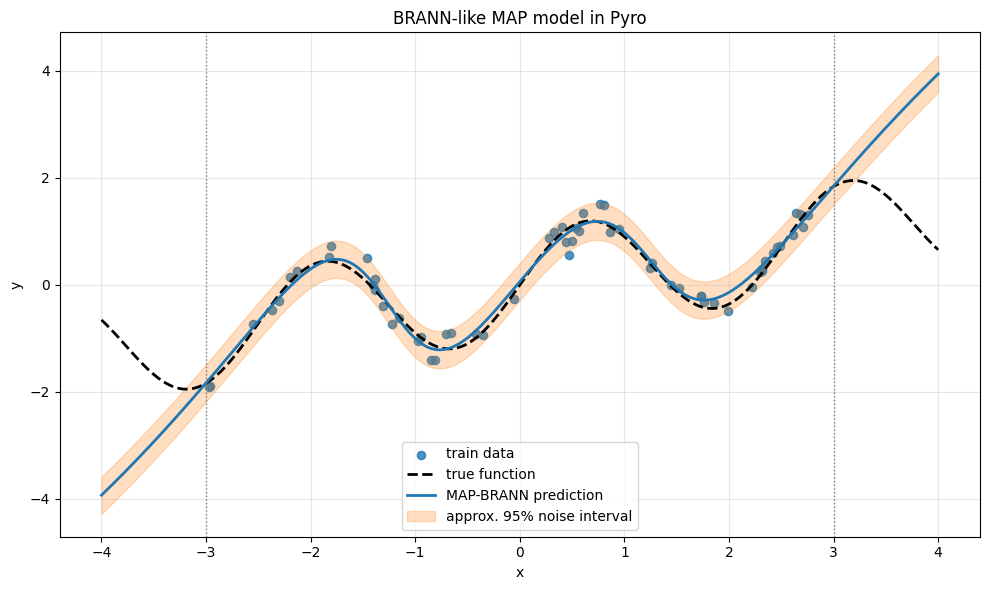

In [ ]:
import math
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam
from torch.distributions import constraints
import matplotlib.pyplot as plt


# -----------------------------
# 1. Настройки
# -----------------------------

pyro.set_rng_seed(42)
torch.manual_seed(42)

N_train = 60
H = 40
num_steps = 8000


# -----------------------------
# 2. Искусственные данные
# -----------------------------

def true_function(x):
    return torch.sin(2.5 * x) + 0.3 * x


noise_std = 0.20

x_train = -3.0 + 6.0 * torch.rand(N_train, 1)
y_clean = true_function(x_train)
y_train = y_clean + noise_std * torch.randn_like(y_clean)

x_grid = torch.linspace(-4.0, 4.0, 400).unsqueeze(-1)
y_grid_true = true_function(x_grid)


# -----------------------------
# 3. Нормализация
# -----------------------------

x_loc = x_train.mean(dim=0, keepdim=True)
x_scale = x_train.std(dim=0, keepdim=True)

y_loc = y_train.mean()
y_scale = y_train.std()

X_train = (x_train - x_loc) / x_scale
Y_train = ((y_train - y_loc) / y_scale).squeeze(-1)

X_grid = (x_grid - x_loc) / x_scale


def inv_y(z):
    return z * y_scale + y_loc


# -----------------------------
# 4. MAP-BRANN модель в Pyro
# -----------------------------

def make_map_brann_model(D, H):
    def model(X, y=None):
        N = X.shape[0]

        zero = X.new_tensor(0.0)

        # alpha — precision весов.
        # Чем больше alpha, тем сильнее L2-регуляризация.
        alpha = pyro.param(
            "alpha",
            X.new_tensor(0.1),
            constraint=constraints.positive
        )

        # beta — precision шума наблюдений.
        beta = pyro.param(
            "beta",
            X.new_tensor(20.0),
            constraint=constraints.positive
        )

        sigma_w = torch.rsqrt(alpha)
        sigma_y = torch.rsqrt(beta)

        # Инициализация весов.
        # Для 1D задачи полезно не делать веса слишком маленькими.
        w1 = pyro.param(
            "w1",
            torch.randn(D, H) * 1.0
        )

        b1 = pyro.param(
            "b1",
            torch.randn(H) * 0.3
        )

        w2 = pyro.param(
            "w2",
            torch.randn(H, 1) * math.sqrt(1.0 / H)
        )

        b2 = pyro.param(
            "b2",
            torch.zeros(1)
        )

        hidden = torch.tanh(X @ w1 + b1)
        mu = (hidden @ w2 + b2).squeeze(-1)

        pyro.deterministic("mu", mu)

        # Prior на веса: w ~ N(0, alpha^{-1})
        weight_log_prior = (
            dist.Normal(zero, sigma_w).log_prob(w1).sum()
            + dist.Normal(zero, sigma_w).log_prob(b1).sum()
            + dist.Normal(zero, sigma_w).log_prob(w2).sum()
            + dist.Normal(zero, sigma_w).log_prob(b2).sum()
        )

        pyro.factor("weight_prior", weight_log_prior)

        # Hyperpriors.
        # alpha prior со средним около 0.5 — не слишком агрессивная регуляризация.
        pyro.factor(
            "alpha_prior",
            dist.Gamma(
                X.new_tensor(1.0),
                X.new_tensor(2.0)
            ).log_prob(alpha)
        )

        # beta prior со средним около 20.
        # В нормализованной шкале это соответствует шуму порядка 1/sqrt(20).
        pyro.factor(
            "beta_prior",
            dist.Gamma(
                X.new_tensor(2.0),
                X.new_tensor(0.1)
            ).log_prob(beta)
        )

        with pyro.plate("data", N):
            pyro.sample("obs", dist.Normal(mu, sigma_y), obs=y)

    return model


def empty_guide(X, y=None):
    pass


# -----------------------------
# 5. Обучение одной MAP-BRANN
# -----------------------------

pyro.clear_param_store()

D = X_train.shape[1]
model = make_map_brann_model(D, H)

optimizer = ClippedAdam({
    "lr": 0.01,
    "clip_norm": 10.0
})

svi = SVI(
    model,
    empty_guide,
    optimizer,
    loss=Trace_ELBO()
)

for step in range(num_steps):
    loss = svi.step(X_train, Y_train) / N_train

    if step % 1000 == 0:
        alpha_val = pyro.param("alpha").item()
        beta_val = pyro.param("beta").item()
        print(
            f"step {step:5d} | loss={loss:.4f} | "
            f"alpha={alpha_val:.4f} | beta={beta_val:.4f}"
        )


# -----------------------------
# 6. Предсказание
# -----------------------------

def forward_from_param_store(X):
    w1 = pyro.param("w1")
    b1 = pyro.param("b1")
    w2 = pyro.param("w2")
    b2 = pyro.param("b2")

    hidden = torch.tanh(X @ w1 + b1)
    mu = (hidden @ w2 + b2).squeeze(-1)

    return mu


with torch.no_grad():
    mu_grid_std = forward_from_param_store(X_grid)
    pred_mean = inv_y(mu_grid_std)

    alpha_final = pyro.param("alpha").item()
    beta_final = pyro.param("beta").item()

    noise_std_norm = 1.0 / math.sqrt(beta_final)
    noise_std_original = noise_std_norm * y_scale.item()

    pred_low = pred_mean - 1.96 * noise_std_original
    pred_high = pred_mean + 1.96 * noise_std_original


print()
print(f"Final alpha: {alpha_final:.4f}")
print(f"Final beta : {beta_final:.4f}")
print(f"Estimated noise std in original scale: {noise_std_original:.4f}")
print(f"True noise std: {noise_std:.4f}")


# -----------------------------
# 7. График
# -----------------------------

x_grid_np = x_grid.squeeze(-1).detach().numpy()

plt.figure(figsize=(10, 6))

plt.scatter(
    x_train.squeeze(-1).numpy(),
    y_train.squeeze(-1).numpy(),
    s=35,
    alpha=0.8,
    label="train data"
)

plt.plot(
    x_grid_np,
    y_grid_true.squeeze(-1).numpy(),
    "k--",
    linewidth=2,
    label="true function"
)

plt.plot(
    x_grid_np,
    pred_mean.detach().numpy(),
    color="tab:blue",
    linewidth=2,
    label="MAP-BRANN prediction"
)

plt.fill_between(
    x_grid_np,
    pred_low.detach().numpy(),
    pred_high.detach().numpy(),
    color="tab:orange",
    alpha=0.25,
    label="approx. 95% noise interval"
)

plt.axvline(-3, color="gray", linestyle=":", linewidth=1)
plt.axvline(3, color="gray", linestyle=":", linewidth=1)

plt.title("BRANN-like MAP model in Pyro")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
